In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../data/emi_prediction_dataset_cleaned.csv")
df.shape

(398456, 31)

In [3]:
X = df.drop(["emi_eligibility", "max_monthly_emi"], axis=1)
y = df["max_monthly_emi"]

In [4]:
cat_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X.dtypes.unique()

array([dtype('float64'), dtype('int64'), dtype('bool')], dtype=object)

In [5]:
joblib.dump(X.columns.tolist(), "../../model_columns.pkl")

['../../model_columns.pkl']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
# param_dist = {
#     "n_estimators": [400, 600, 800],
#     "learning_rate": [0.01, 0.03, 0.05, 0.1],
#     "max_depth": [4, 5, 6, 7, 8],
#     "subsample": [0.7, 0.8, 0.9],
#     "colsample_bytree": [0.7, 0.8, 0.9]
# }

# xgb = XGBRegressor(
#     random_state=42,
#     n_jobs=-1
# )

# random_search = RandomizedSearchCV(
#     estimator=xgb,
#     param_distributions=param_dist,
#     n_iter=15,
#     scoring="r2",
#     cv=3,
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )

# random_search.fit(X_train, y_train)

# print("Best Parameters:", random_search.best_params_)
# print("Best CV Score:", random_search.best_score_)

In [8]:
# Best Parameters: {'subsample': 0.9, 'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.9}

In [9]:
xgb_reg = XGBRegressor(
    n_estimators=800,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs= -1
)
xgb_reg.fit(X_train, y_train)
y_pred = xgb_reg.predict(X_test)
y_train_pred = xgb_reg.predict(X_train)

In [10]:
rmse = root_mean_squared_error(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
mae = mean_absolute_error(y_train, y_train_pred)
r2 = r2_score(y_train, y_train_pred)

print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 416.2164517526211
MSE: 173236.13470954195
MAE: 226.13039967626338
R2 Score: 0.9971178949019718


In [11]:
rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 685.7520293024239
MSE: 470255.84569239244
MAE: 280.6419128867486
R2 Score: 0.9921367294723018


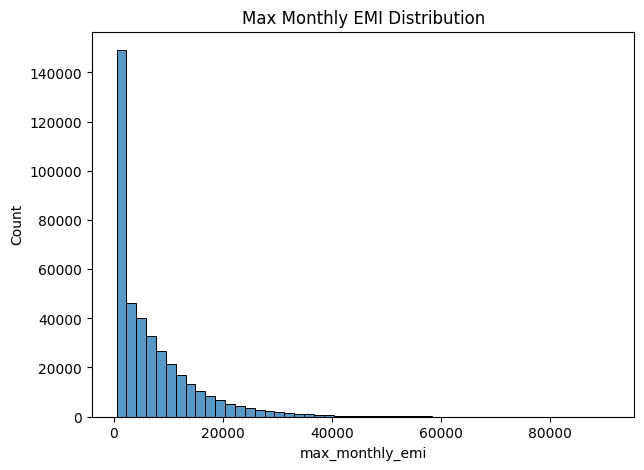

In [12]:
plt.figure(figsize=(7,5))
sns.histplot(df['max_monthly_emi'], bins=50)
plt.title("Max Monthly EMI Distribution")
plt.show()

In [13]:
xgb_reg.feature_importances_

array([1.28784319e-04, 8.18050131e-02, 5.14955353e-03, 4.74861450e-03,
       2.95038510e-04, 1.06251496e-03, 1.23718602e-03, 2.93340813e-03,
       1.08479767e-03, 1.74511950e-02, 6.23878383e-04, 1.83500685e-02,
       1.85016990e-02, 1.68631375e-02, 2.82596773e-03, 2.67892407e-04,
       3.01775959e-04, 1.15981710e-03, 1.72417127e-02, 1.15165979e-01,
       2.43971065e-01, 2.44419178e-04, 1.67794584e-04, 2.92310346e-04,
       3.47353227e-04, 1.16315391e-03, 1.00989565e-02, 8.07169173e-03,
       2.17254346e-04, 2.14003318e-04, 2.32457605e-04, 2.87113973e-04,
       1.17962016e-03, 2.31041126e-02, 4.02038813e-01, 2.80281150e-04,
       2.37678294e-04, 2.93170684e-04, 3.60688195e-04], dtype=float32)

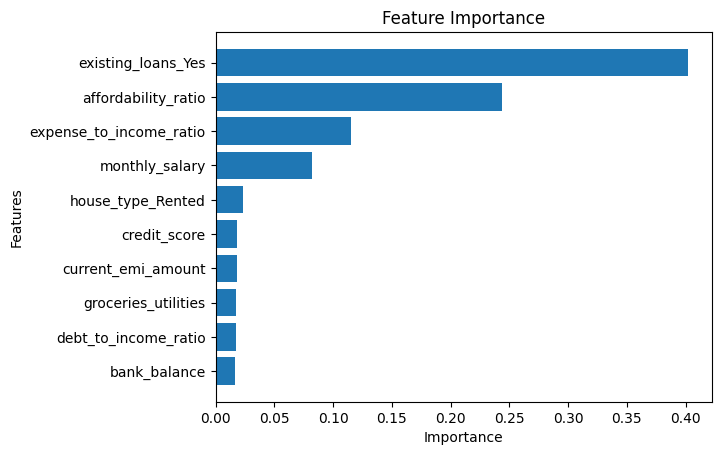

In [14]:
import matplotlib.pyplot as plt
importance_df = pd.DataFrame({
    "features": X.columns,
    "importance": xgb_reg.feature_importances_
})
importance_df = importance_df.sort_values("importance", ascending=False).head(10)

plt.figure()
plt.barh(importance_df["features"], importance_df["importance"])
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()